# P(k) vs P(k)+B(k): the validated, properly marginalized analysis

This notebook supersedes the geometry results of `06_fisher_pk_bk.ipynb`. Three things went
wrong there, and each is fixed here.

1. **A numerical artifact posed as a measurement.** With pybird's AP volume factor, rescaling
   $h_{\rm conv}$, every $D_A$ and $1/H$ together is an **exact** symmetry of the continuum model
   ($h_{\rm conv}$ is the ruler length in Mpc/$h$). Interpolation breaks it at $\sigma \approx 0.05$,
   and the Fisher matrix read that breaking as information. The per-redshift $H$ and $D_A$ of
   06 (~5%, redshift-independent, "halved by B") were that artifact. Here the data's response along
   the exact symmetries is projected out; priors are left free to constrain those directions.
2. **The wrong model.** 06 freed 80 emulator knots with no prior, a degenerate model the HMC never
   samples. Here the Fisher uses the HMC's model exactly: 60 ln-$a$ nodes (spacing 0.15 in ln $k$)
   and the `setups.COMMON` priors ($\sigma_{\ln a}=0.5$, $\lambda=200$, $\sigma_{\ln g}=0.3$,
   $\sigma_{\ln h}=0.05$). It reproduces the HMC chain's per-node widths to **5%**.
3. **Marginalization precision.** Every marginal comes from the whitened Jacobian (SVD or a
   well-conditioned inverse with the priors), never from an explicit $J^TPJ$ at the noise floor.

Superseded figures are in `output/fisher_pb/superseded/` with a README saying why.

In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('07_robust_pk_bk.ipynb')))
if not os.path.exists('../../output/fisher_pb/jacobians_pb.npz'):
    %run jacobian_pb.py
else:
    print('using cached ../../output/fisher_pb/jacobians_pb.npz  (delete it to recompute, ~5 min)')

using cached ../../output/fisher_pb/jacobians_pb.npz  (delete it to recompute, ~5 min)


## 1. The Fisher reproduces the HMC, and the band recovery

v3's own P(k)-only Fisher, put into the HMC's node basis with the HMC's priors, is compared
node-by-node with the standard deviation of the chain (`hmc_v3_p5/chain_mi.npz`). The same priors
are then applied to the P and P+B systems.

Expected: Fisher/chain ≈ 1.05, and the bispectrum barely moves the template bands (≈0.11 → 0.10
per node in the data range) because they are already prior-limited. Note: the absolute $\ln D_A$,
$\ln H$ table this script prints does **not** project the ruler symmetry, so it includes the
artifact; use section 2 for geometry. (Not projecting is right for the chain comparison itself: the
chain samples the same discretized model.)

In [2]:
%run hmc_prior_bands.py

node basis: 60 nodes over [0.0001, 0.7] h/Mpc, spacing 0.15 in ln k -> 80 knots; row sums of S (should be 1): 1.0000..1.0000


VALIDATION: v3's own P(k) Fisher in the HMC's node basis + the HMC priors, versus the standard deviation of the HMC chain itself.


   v3 Fisher + MI priors: min eigenvalue 6.996e-03 (must be > 0)


   HMC chain: 32 chains x 2000 draws, 106 params = 21 EFT + 60 nodes + 25 growth


   sigma(ln a) per node, Fisher / chain:  median 1.053, in the data range 1.055  (range 1.00-1.32)


...

      lnDA  P          0.0342       0.0326       0.0320       0.0322       0.0330       0.0655


      lnDA  P+B        0.0314       0.0298       0.0293       0.0294       0.0299       0.0640


      lnH   P          0.0411       0.0370       0.0355       0.0347       0.0352       0.0763


      lnH   P+B        0.0382       0.0340       0.0325       0.0318       0.0325       0.0747



saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/hmc_prior_bands.png


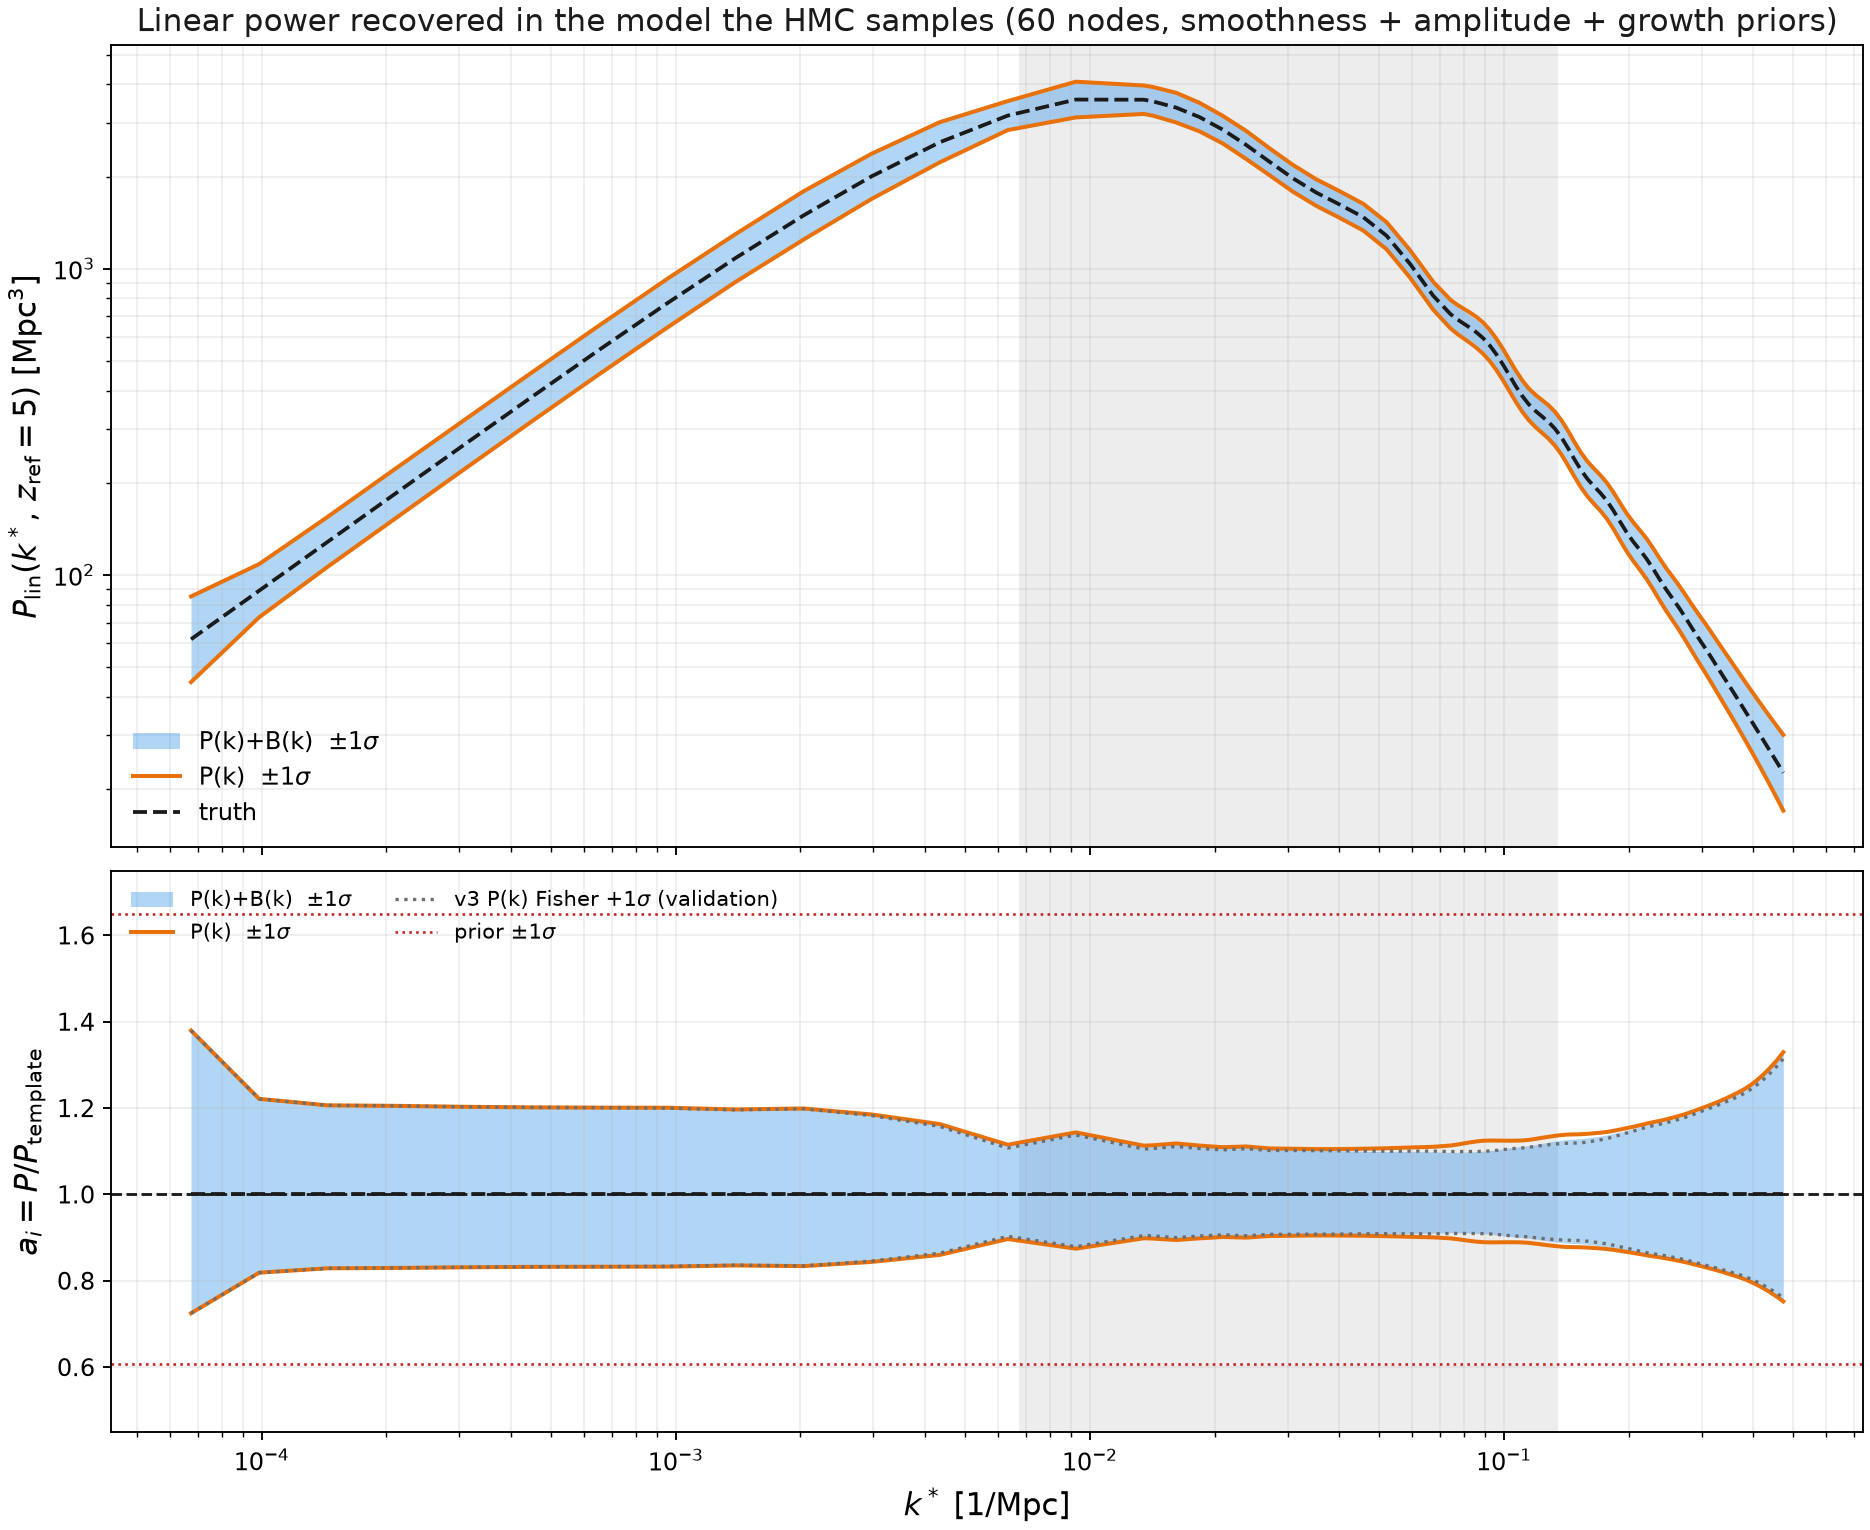

In [3]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/hmc_prior_bands.png', width=850))

## 2. The all-z AP corner, and are the priors fair?

`corner_ap_all_z_mi.png` is the 12-parameter ($\ln H$, $\ln D_A$ at six redshifts) corner in the HMC
model, with the symmetry breaking projected out of the data. The widths (~4.7%, nearly the same at
every $z$ and for both data sets) are the **ruler**: the direction "every $D_A$ up, every $H$ down"
has $\sigma = 0.165$ in the posterior against $0.156$ from the prior alone, so the data add nothing
to it. Projecting that one direction out (`..._rulerfree.png`) leaves what the data measure,
~1.5–2%.

The audit then asks whether the priors are fair:
- **Effective data-constrained dof** per block: EFT all; template 14 of 60; $h_{\rm conv}$ 0.2 of 1.
- **Real cosmologies are allowed:** a Planck-1σ shift in $\omega_{\rm cdm}$ costs prior
  $\chi^2 = 0.06$, 5σ costs 1.3 (sanity checks: constant or linear ln $a$ give exactly zero
  smoothness penalty).
- **But the ruler is loose:** a 1% dilation of the template costs only $\chi^2 = 0.38$, so the
  prior lets the BAO feature slide by 1.6%.

In [4]:
%run corner_audit_pb.py

P   : 183 params (14x7 EFT + 60 nodes + 25 growth); min eig 1.000e+00; the data's own (spurious) sigma along g1/g2/g3 = 0.0496, 4.05e+03, 0.228  (projected out)


P+B : 197 params (16x7 EFT + 60 nodes + 25 growth); min eig 1.000e+00; the data's own (spurious) sigma along g1/g2/g3 = 0.0496, 4.05e+03, 0.217  (projected out)


CORNER quantities: fractional 1 sigma of ln H and ln D_A per redshift, MI model, everything marginalized.


                 z=0.295     z=0.510     z=0.706     z=0.930     z=1.317     z=1.491


lnDA   P          0.0477      0.0469      0.0466      0.0466      0.0470      0.0730


...

   volume ratio |C_PB|^(1/12) / |C_P|^(1/12) = 0.9775



saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/corner_ap_all_z_mi.png


/users/areeves/pybird/jax_env/lib/python3.12/site-packages/getdist/gaussian_mixtures.py:43: RuntimeWarning: invalid value encountered in sqrt
  self.norms = (2 * np.pi) ** (0.5 * self.dim) * np.array([np.sqrt(np.linalg.det(cov)) for cov in self.covs])


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/corner_ap_all_z_mi_rulerfree.png


saved per-redshift corners corner_growth_z*_mi.png


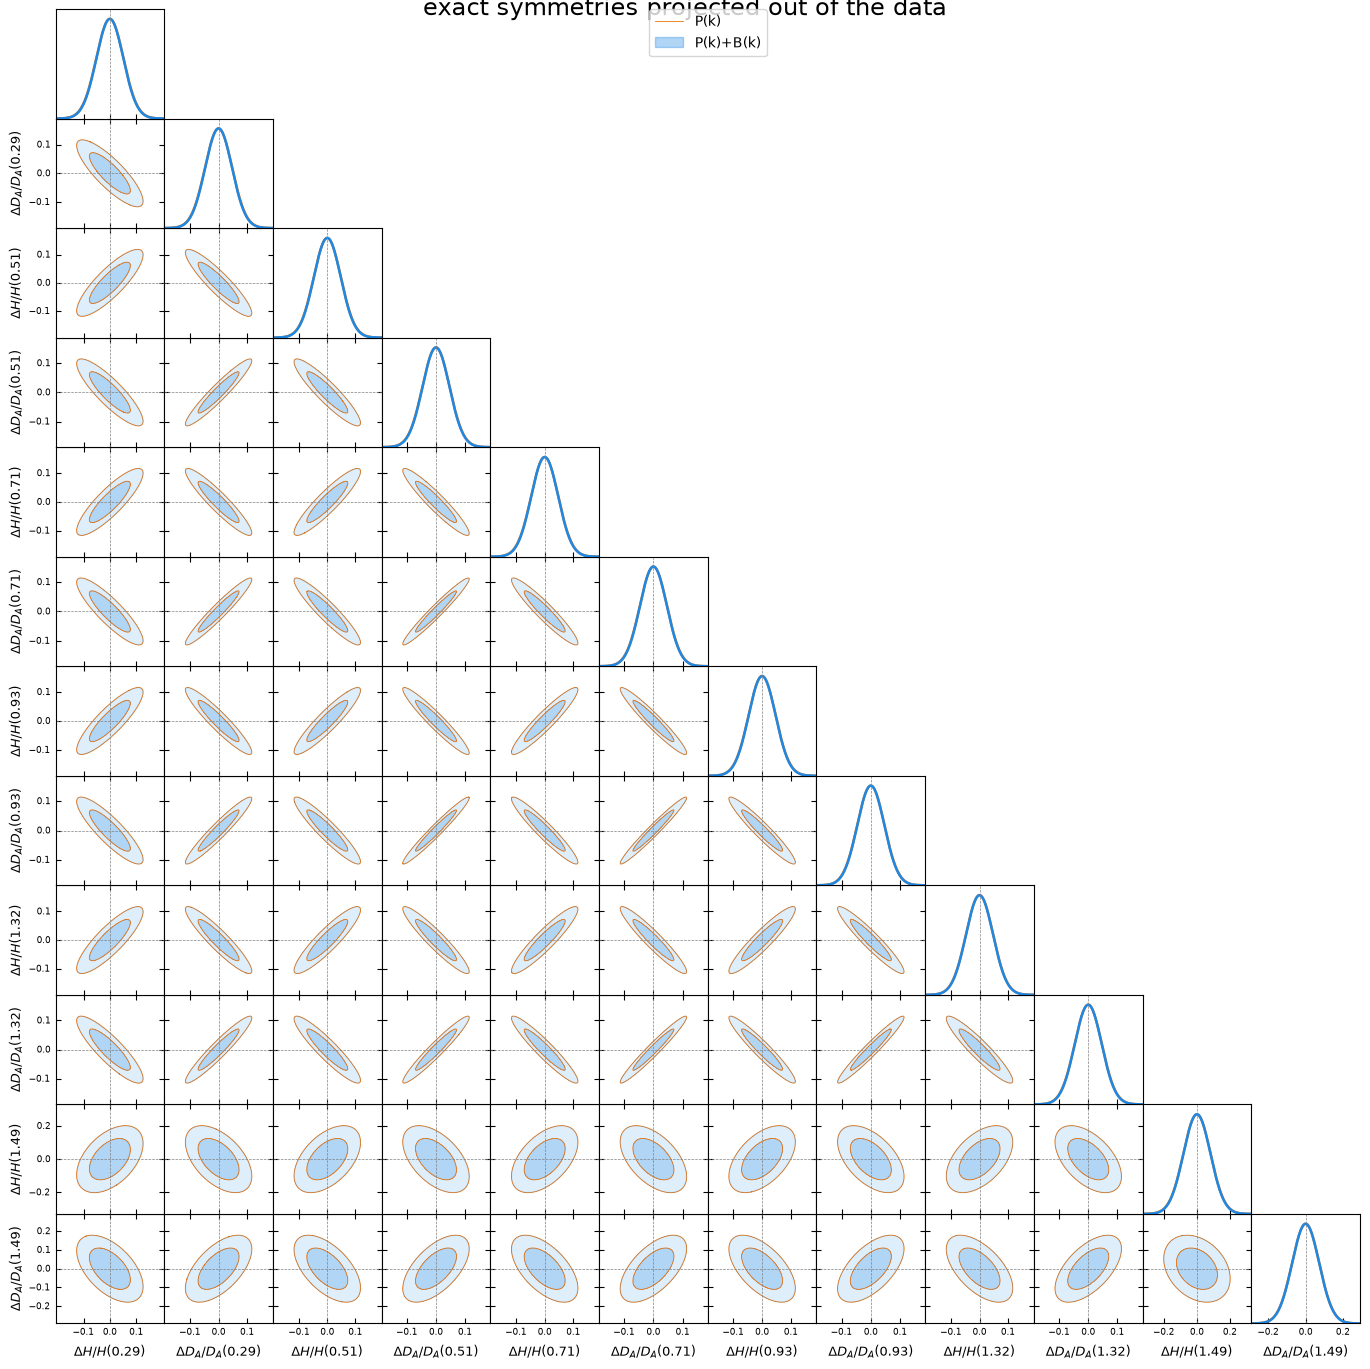

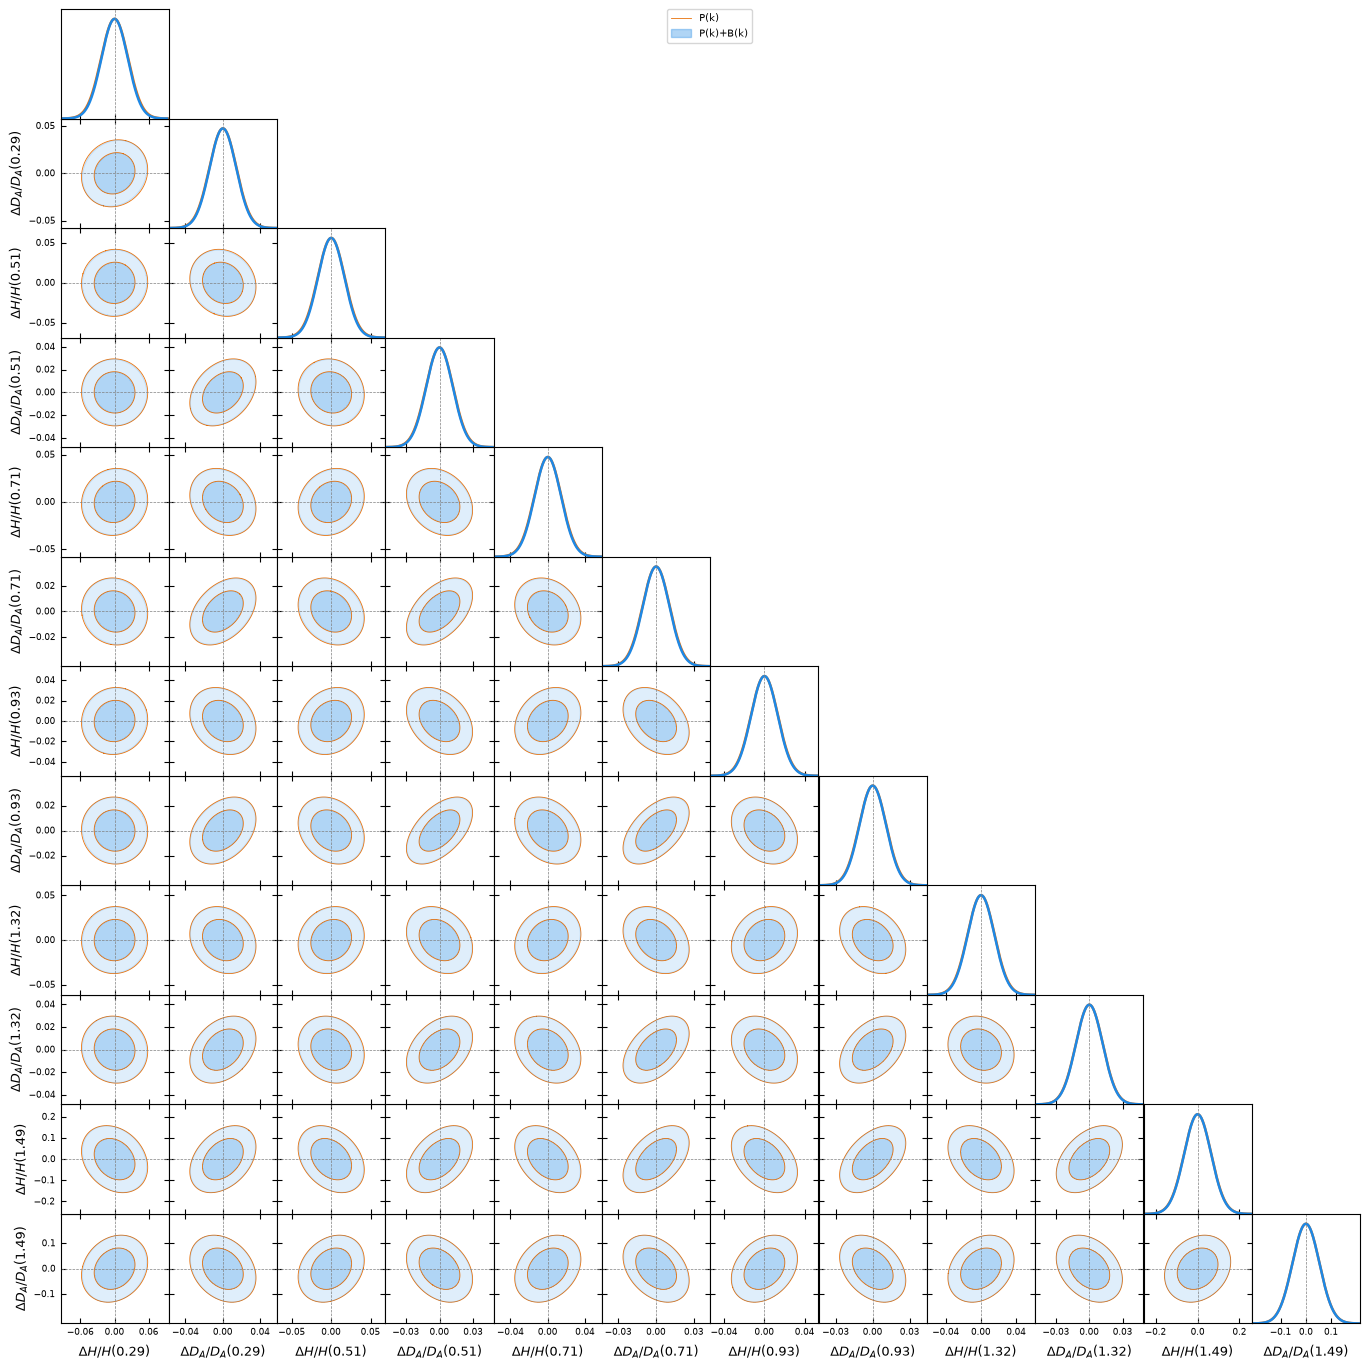

In [5]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/corner_ap_all_z_mi.png', width=900))
display(Image(filename='../../output/fisher_pb/corner_ap_all_z_mi_rulerfree.png', width=900))

## 3. Why it is not yet a BAO method, and the basis that makes it one

A BAO oscillation spans 0.60 in ln $k$; the HMC's nodes are 0.15 apart, about four per wiggle, so
the template can slide its own BAO feature. Coarsening the nodes past the BAO period makes the
wiggle shape rigid, which is exactly what a BAO fit assumes, while the broadband stays free. The
BAO parameters $D_M/r_d = \ln D_A - \ln h_{\rm conv}$ and $D_H/r_d = -\ln H - \ln h_{\rm conv}$
are invariant under the ruler symmetry, so they are measurable without any $h$ prior.

Expected at $z=0.71$: $\sigma(D_M/r_d)$ 2.1% → 0.71% and $\sigma(D_H/r_d)$ 2.4% → 1.3% as the
spacing goes 0.15 → ≥0.4, saturating at the fixed-template answer. $F_{\rm AP}$ needs no ruler and
does not move. The bispectrum's gain is on $f$ (×~2), not on the geometry.

In [6]:
%run bao_basis_scan.py

BAO oscillation period in ln k at k=0.1 h/Mpc: 0.60  (2pi/(r_d k), r_d=105 Mpc/h)
 spacing  nodes  dilation in basis  prior sig(ruler)                  sigma(alpha_perp)                   sigma(alpha_par)         sigma(F_AP)
                                                                 P        P+B     ratio             P        P+B     ratio         P       P+B
    0.15     60              0.999            0.0018     0.0213   0.0194  0.913           0.0237   0.0217  0.915           0.0162   0.0159


    0.25     36              0.995            0.0000     0.0108   0.0105  0.974           0.0156   0.0150  0.964           0.0160   0.0156
    0.40     23              0.992            0.0318     0.0075   0.0073  0.975           0.0133   0.0128  0.962           0.0159   0.0156
    0.60     16              0.992            0.0373     0.0071   0.0069  0.972           0.0130   0.0126  0.970           0.0158   0.0155
    0.90     11              0.991            0.0417     0.0071   0.0069  0.970           0.0129   0.0126  0.973           0.0157   0.0154


    1.40      7              0.991            0.0495     0.0071   0.0069  0.969           0.0129   0.0126  0.974           0.0157   0.0154

(z = 0.706; 'dilation in basis' = |P_basis gamma| / |gamma|, the fraction of a pure template
 dilation the node basis can absorb; 1 = the template is its own ruler.)

Per-redshift fractional 1 sigma (HMC priors, data-side g1/g2 projected):
                                 z=0.295   z=0.510   z=0.706   z=0.930   z=1.317   z=1.491
HMC model (60  perp  P             0.0238    0.0220    0.0213    0.0214    0.0224    0.0612
HMC model (60  perp  P+B           0.0219    0.0202    0.0194    0.0196    0.0205    0.0604
HMC model (60  par   P             0.0312    0.0256    0.0237    0.0229    0.0241    0.0727
HMC model (60  par   P+B           0.0292    0.0236    0.0217    0.0211    0.0227    0.0715
HMC model (60  F_AP  P             0.0290    0.0201    0.0162    0.0148    0.0180    0.0924
HMC model (60  F_AP  P+B           0.0285    0.0198    0.0159    0.01

saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/bao_summary_pb.png


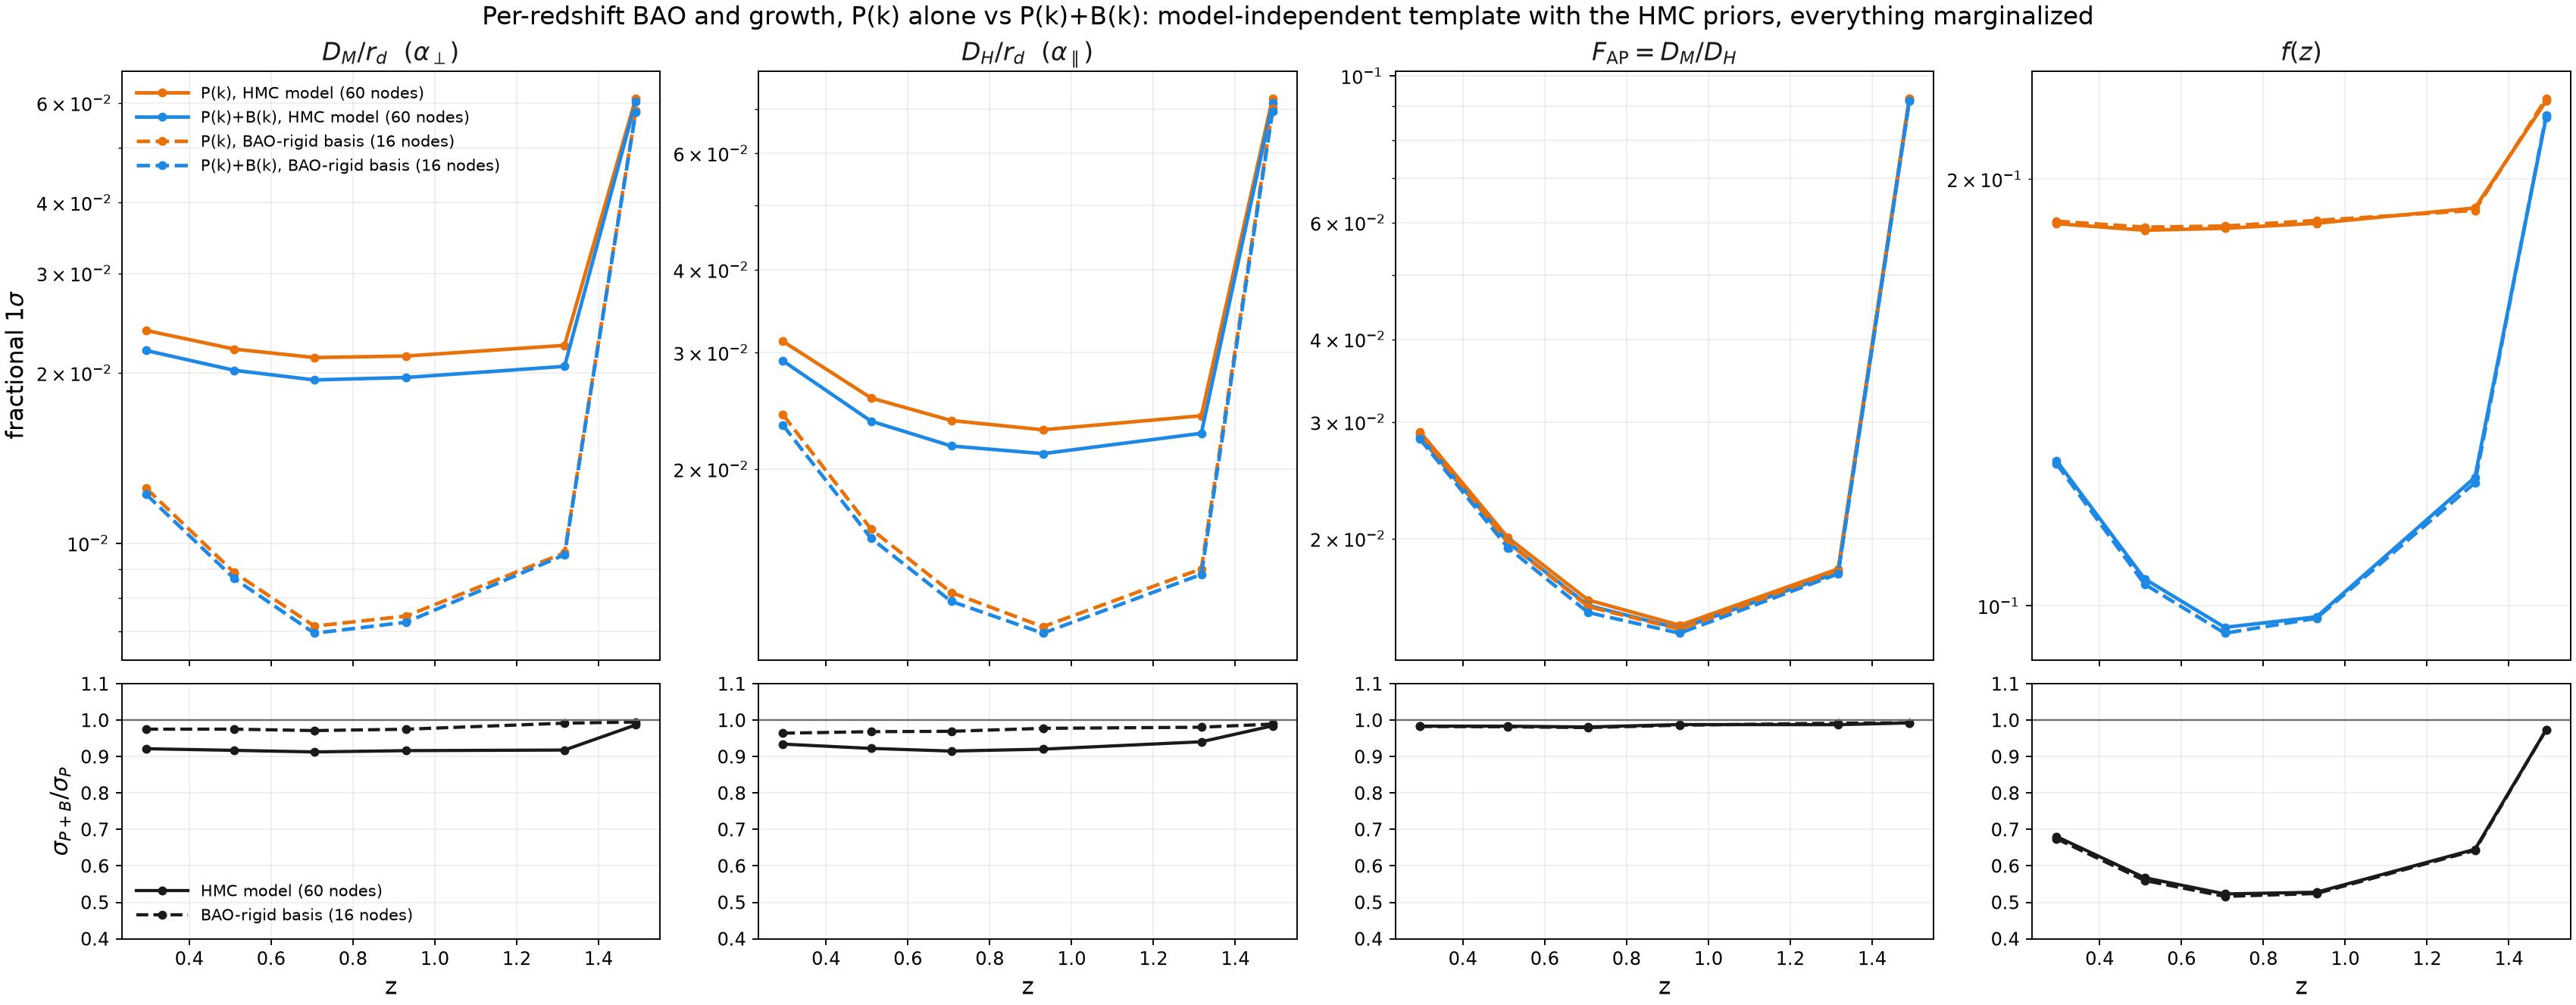

In [7]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/bao_summary_pb.png', width=1100))

## Summary

| | HMC model (60 nodes) | BAO-rigid basis (16 nodes) |
|---|---|---|
| $\sigma(D_M/r_d)$, $z=0.71$, P → P+B | 2.13% → 1.94% | 0.71% → 0.69% |
| $\sigma(D_H/r_d)$ | 2.37% → 2.17% | 1.30% → 1.26% |
| $\sigma(F_{\rm AP})$ | 1.62% → 1.59% | 1.58% → 1.55% |
| $\sigma(f)$ | 18.5% → 9.7% | 18.5% → 9.6% |

- Absolute $H(z)$ and $D_A(z)$ are set by the $h_{\rm conv}$ and growth priors in this model; no
  data can fix them.
- The bispectrum improves the growth rate by about a factor two and the geometry by a few percent.
- The bispectrum here is tree-level; one-loop is `with_bk_tree_level: False` plus
  `bk_loop_matrix_path` in `run_fisher_pb.py`, then `jacobian_pb.py` again.